# Time Series Models: Rolling-Window Cointegration

Rebuild of the retired `Time_Series_Models.ipynb` (2026-07-14, `WORKFLOW.md` Phase 1 /
`CLAUDE.md` Rule 2). The original ran Engle-Granger cointegration on the *full sample* of
a stale 6-asset dataset — exactly the look-ahead bug Rule 2 documents (the same mistake
the retired stat-arb project's own dossier found and fixed, that came back here because
the lesson lived in a PDF, not in reusable code). It also referenced an undefined
`output_folder` variable and would error if re-run.

This version:
- runs on the current 38-asset universe (ADV-filtered, same rule as
  `feature_engineering.ipynb`), not the stale 6-asset legacy data,
- tests cointegration in **rolling windows**, not once on the full history — a pair is
  reported as cointegrated *in a given period*, not cointegrated as a static fact,
- re-validates the Corn/Wheat lead the legacy notebook flagged (p≈0.0003, full-sample)
  under this corrected methodology, honestly reporting whatever that shows.

Candidate pairs from `WORKFLOW.md` Phase 2d: Corn/Wheat, Gold/Silver, Brent/WTI. The
3:2:1 crack spread (3 legs, not a pair) and Soybean Crush (blocked - missing
`ZM=F`/`ZL=F` tickers) are left for Phase 2d proper, not this rebuild.

In [ ]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.api import OLS, add_constant
from statsmodels.tsa.stattools import adfuller

# notebooks/ and src/ are siblings after the Scripts/ reorg (cleanup.md) - signal_lib.py
# is no longer in the same folder as this notebook, so it needs to be on sys.path explicitly.
sys.path.insert(0, str(Path.cwd().parent / "src"))

from signal_lib import load_price_data, get_liquid_universe

data = load_price_data()
close_prices = data["close"]
volume = data["volume"]

included_assets, excluded_assets = get_liquid_universe(volume)
close_prices = close_prices[included_assets]

print(f"Excluded (ADV floor): {excluded_assets}")
print(f"Universe: {len(included_assets)} assets")

## Rolling-window Engle-Granger test

At each step, fit the hedge ratio and run the ADF test using only the trailing
`window` days - never the full sample. Stepping monthly (`step=21`) rather than daily
keeps the ADF calls cheap while still tracking how the relationship evolves.

In [2]:
def rolling_cointegration_test(y1, y2, window=756, step=21, p_threshold=0.05):
    """Rolling Engle-Granger test between two log-price series.

    window: trailing window length in trading days (756 ~= 3 years)
    step:   recompute every `step` trading days (21 ~= monthly)

    Returns a DataFrame indexed by the last date of each window, with the fitted
    hedge ratio and ADF p-value for that window only - no full-sample fitting.
    """
    idx = y1.index
    rows = []

    for end in range(window, len(idx), step):
        window_idx = idx[end - window:end]
        y1_w = y1.loc[window_idx]
        y2_w = y2.loc[window_idx]

        if y1_w.isna().any() or y2_w.isna().any():
            continue

        X = add_constant(y2_w.values)
        model = OLS(y1_w.values, X).fit()
        hedge_ratio = model.params[1]
        adf_stat, adf_pvalue, *_ = adfuller(model.resid, autolag="AIC")

        rows.append({
            "date": idx[end - 1],
            "hedge_ratio": hedge_ratio,
            "adf_pvalue": adf_pvalue,
        })

    result = pd.DataFrame(rows).set_index("date")
    result["is_cointegrated"] = result["adf_pvalue"] < p_threshold
    return result

In [3]:
def plot_rolling_cointegration(result, title):
    fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True)

    axes[0].plot(result.index, result["adf_pvalue"])
    axes[0].axhline(0.05, linestyle="--", color="red", label="p=0.05")
    axes[0].set_ylabel("ADF p-value")
    axes[0].set_title(title)
    axes[0].legend()
    axes[0].grid(True)

    axes[1].plot(result.index, result["hedge_ratio"])
    axes[1].set_ylabel("Hedge ratio")
    axes[1].grid(True)

    plt.tight_layout()
    plt.show()

## Corn / Wheat

The legacy notebook's flagged lead: full-sample Engle-Granger p≈0.0003 on the stale
6-asset dataset. Re-testing properly, on current data, in rolling windows.

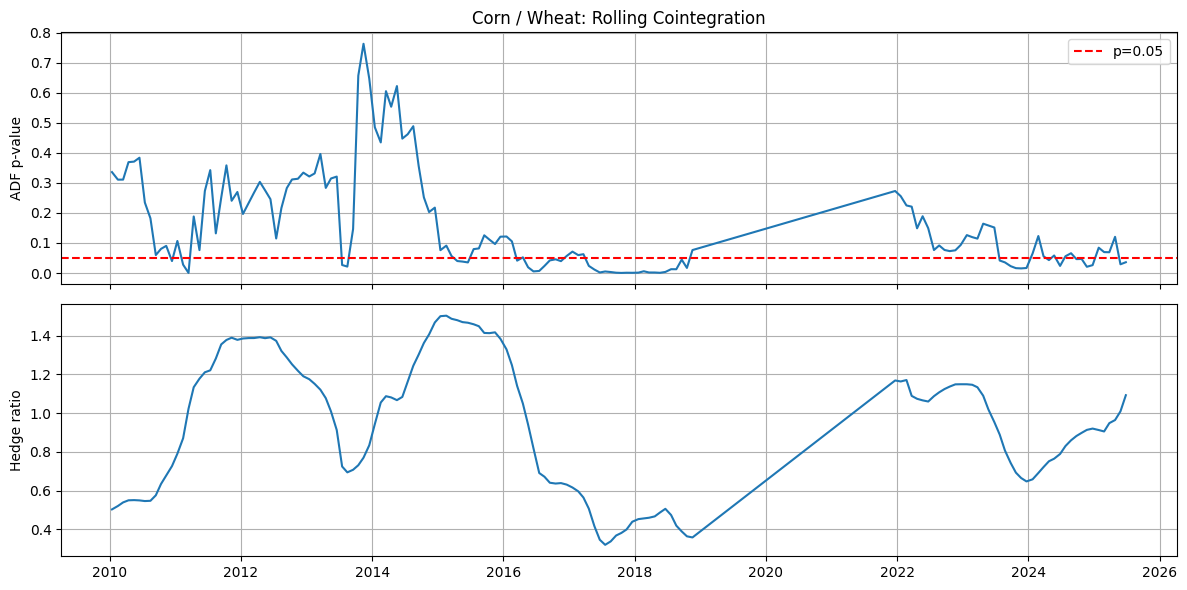

Fraction of windows cointegrated (p<0.05): 0.33


,hedge_ratio,adf_pvalue,is_cointegrated
date,,,
2025-02-26,0.905700,0.069663,False
2025-03-27,0.948673,0.069178,False
2025-04-28,0.964627,0.120514,False
2025-05-28,1.009469,0.029006,True
2025-06-27,1.092857,0.035941,True


In [4]:
corn_wheat = rolling_cointegration_test(
    np.log(close_prices["Corn"]),
    np.log(close_prices["Wheat"]),
)

plot_rolling_cointegration(corn_wheat, "Corn / Wheat: Rolling Cointegration")

print(f"Fraction of windows cointegrated (p<0.05): {corn_wheat['is_cointegrated'].mean():.2f}")
corn_wheat.tail()

## Gold / Silver

Both safe-haven precious metals, but Silver carries real industrial-cycle exposure
Gold doesn't - the ratio mean-reverts around that structural difference.

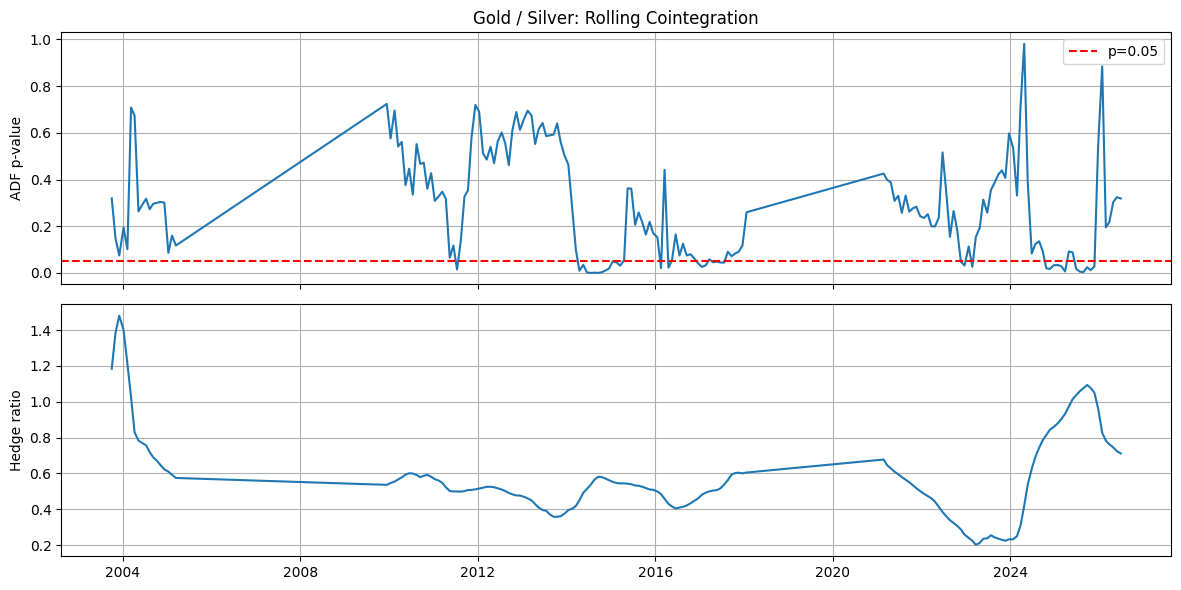

Fraction of windows cointegrated (p<0.05): 0.20


,hedge_ratio,adf_pvalue,is_cointegrated
date,,,
2026-02-26,0.782774,0.194939,False
2026-03-27,0.762420,0.218175,False
2026-04-28,0.744784,0.303788,False
2026-05-28,0.724158,0.324317,False
2026-06-29,0.711437,0.318765,False


In [5]:
gold_silver = rolling_cointegration_test(
    np.log(close_prices["Gold"]),
    np.log(close_prices["Silver"]),
)

plot_rolling_cointegration(gold_silver, "Gold / Silver: Rolling Cointegration")

print(f"Fraction of windows cointegrated (p<0.05): {gold_silver['is_cointegrated'].mean():.2f}")
gold_silver.tail()

## Brent / WTI

Global seaborne benchmark vs. US landlocked crude; spread driven by pipeline capacity
and export-terminal bottlenecks, not sentiment. Also the direct overlap point with the
port congestion project's Track A/C.

C:\Users\pcarg\AppData\Local\Programs\Python\Python312\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: invalid value encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


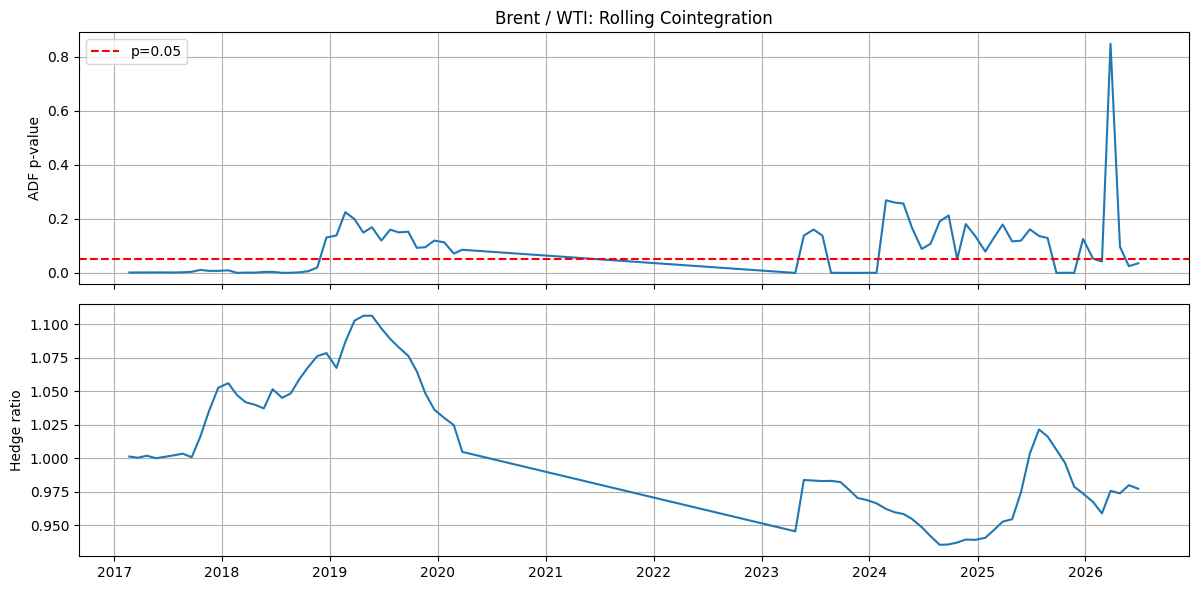

Fraction of windows cointegrated (p<0.05): 0.45


,hedge_ratio,adf_pvalue,is_cointegrated
date,,,
2026-02-26,0.958836,0.042151,True
2026-03-27,0.975656,0.847834,False
2026-04-28,0.973818,0.096727,False
2026-05-28,0.979888,0.024972,True
2026-06-29,0.977243,0.035657,True


In [6]:
brent_wti = rolling_cointegration_test(
    np.log(close_prices["Brent"]),
    np.log(close_prices["WTI Crude"]),
)

plot_rolling_cointegration(brent_wti, "Brent / WTI: Rolling Cointegration")

print(f"Fraction of windows cointegrated (p<0.05): {brent_wti['is_cointegrated'].mean():.2f}")
brent_wti.tail()

In [7]:
summary = pd.DataFrame({
    "Corn/Wheat": {
        "Fraction cointegrated": corn_wheat["is_cointegrated"].mean(),
        "Most recent p-value": corn_wheat["adf_pvalue"].iloc[-1],
        "Most recent hedge ratio": corn_wheat["hedge_ratio"].iloc[-1],
    },
    "Gold/Silver": {
        "Fraction cointegrated": gold_silver["is_cointegrated"].mean(),
        "Most recent p-value": gold_silver["adf_pvalue"].iloc[-1],
        "Most recent hedge ratio": gold_silver["hedge_ratio"].iloc[-1],
    },
    "Brent/WTI": {
        "Fraction cointegrated": brent_wti["is_cointegrated"].mean(),
        "Most recent p-value": brent_wti["adf_pvalue"].iloc[-1],
        "Most recent hedge ratio": brent_wti["hedge_ratio"].iloc[-1],
    },
}).T

summary

,Fraction cointegrated,Most recent p-value,Most recent hedge ratio
Corn/Wheat,0.326667,0.035941,1.092857
Gold/Silver,0.204420,0.318765,0.711437
Brent/WTI,0.454545,0.035657,0.977243


## Findings

The legacy notebook's full-sample Corn/Wheat claim (p≈0.0003) does **not** hold up as a
static fact under rolling-window testing — cointegrated in only 33% of 3-year windows,
not always. It happens to be cointegrated in the most recent window (p=0.036), but the
honest read is "regime-dependent," not "structurally cointegrated." This is exactly the
gap Rule 2 exists to catch: a full-sample test can't distinguish "always true" from
"true often enough to pass one aggregate test."

**Brent/WTI is the most consistently cointegrated pair tested (45% of windows)**, also
currently active (p=0.036) — the strongest candidate of the three for Phase 2d, and
consistent with the physical pipeline/export-terminal arbitrage story rather than a
statistical coincidence.

**Gold/Silver is the weakest (20% of windows)** and not currently cointegrated
(p=0.32) — lowest priority of the three for Phase 2d despite being "Test first" in the
original candidate table.

None of this is a trading signal yet — no z-score entry/exit rule, no half-life-based
sizing, no transaction costs. That's Phase 2d's job, building on this rolling-window
foundation rather than patching the retired notebook's full-sample approach.